# Assignment 1 -- Fourier Analysis (58 points)


---

### Before you start

As many of you have not worked with Fourier Analysis before, this assignment is designed to help you get some experience working with Fourier Transforms (both with pen and paper calculations and in the context of programs)

**Questions 1 and 2 must be solved without a computer** You can use a calculator. You can write code to check your work. Honesty is expected.

**Questions 3 to 7 use Python.** Backbone code is provided; you fill in the marked sections.
For Questions 3 and 4 you are asked to **write down a prediction before you run anything**.
Points will not be deducted for wrong predictions, but you're expected to explain why you predicted wrongly, and what you learnt from the mistake.

Answer in the markdown cells provided. Keep code and prose together — a plot with no
sentence explaining it earns nothing.

You are expected to provide an explanation for each question. Programs unaccompanied by qualitative and/or quantitative interpretations will be penalized.

### Submitting

Submit this notebook with all cells run, plus an HTML or PDF export. 
Describe every figure you produce in one sentence in the text, so the notebook is
followable without seeing the images.

### Notation

$N$ is the length of a discrete signal, $u$ and $v$ index frequency, $n$ and $m$ index position.

$$\mathscr{L}[u] \;=\; \sum_{n=0}^{N-1} \ell[n]\,\exp\!\left(-\frac{2\pi j\,un}{N}\right)$$


## Setup

Run these cells first.

In [ ]:
#Instructions: 1. Run the following on terminal (not notebook!)
#2. Restart the notebook server
#3. Choose "Computer Vision" as the kernel

python3.10 -m venv ~/cvenv
source ~/cvenv/bin/activate
pip install --upgrade pip
pip install "numpy>=2" "scipy>=1.14" "matplotlib>=3.9" jupyter
python -m ipykernel install --user --name cv --display-name "Computer Vision"

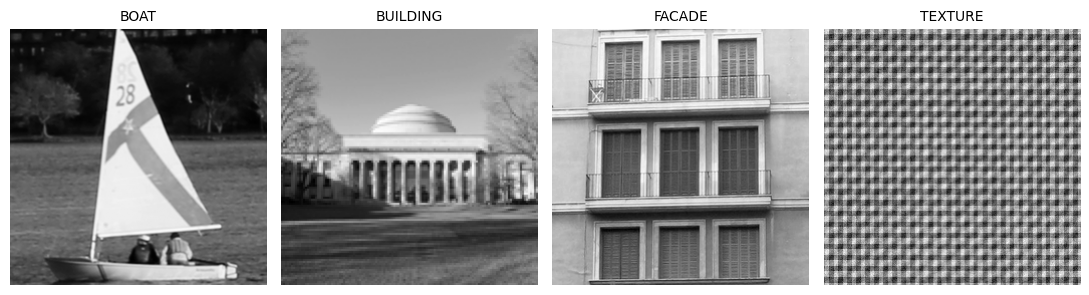

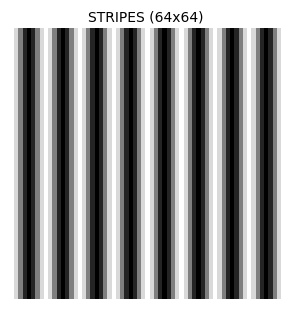

shapes: (256, 256) (256, 256) (256, 256) (256, 256) (64, 64)


In [1]:
# Run this cell first to the images and define a few helpers.
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft, ifft, fft2, ifft2, fftshift, ifftshift

plt.rcParams["figure.figsize"] = (11, 3.2)
plt.rcParams["image.cmap"] = "gray"

def load(name):
    """Load one of the provided images as a float array in [0, 1]."""
    return plt.imread(f"images/{name}.png").astype(float)[..., 0] \
           if plt.imread(f"images/{name}.png").ndim == 3 \
           else plt.imread(f"images/{name}.png").astype(float)

def show(*pairs):
    """show(img, "title", img2, "title2", ...) - display images side by side."""
    imgs = pairs[0::2]; titles = pairs[1::2]
    fig, axes = plt.subplots(1, len(imgs))
    if len(imgs) == 1: axes = [axes]
    for ax, im, t in zip(axes, imgs, titles):
        ax.imshow(im); ax.set_title(t, fontsize=10); ax.axis("off")
    plt.tight_layout(); plt.show()

def spectrum(img):
    """Log amplitude spectrum, origin at the centre. Use this for every
    spectrum you plot - a raw spectrum shows one bright dot and nothing else."""
    return np.log1p(np.abs(fftshift(fft2(img))))

BOAT     = load("boat")       # 256x256, a natural scene with strong contours
BUILDING = load("building")   # 256x256, strong oriented edges
FACADE   = load("facade")     # 256x256, a building facade - note the windows
TEXTURE  = load("texture")    # 256x256, a woven cloth - strongly periodic
STRIPES  = load("stripes")    #   64x64, vertical stripes, period exactly 8 px

show(BOAT, "BOAT", BUILDING, "BUILDING", FACADE, "FACADE", TEXTURE, "TEXTURE")
show(STRIPES, "STRIPES (64x64)")
print("shapes:", BOAT.shape, BUILDING.shape, FACADE.shape, TEXTURE.shape, STRIPES.shape)

---

## Question 1 — 10 points

**Do this question without a computer.** Write your working in the answer cell.
The discrete Fourier transform of a length-$N$ signal is

$$\mathscr{L}[u] \;=\; \sum_{n=0}^{N-1} \ell[n]\,\exp\!\left(-\frac{2\pi j\,un}{N}\right)$$

**(a) [3]** Write down the four values of $\exp(-2\pi j\,k/4)$ for $k=0,1,2,3$. Each is one of $1$, $-1$, $j$, $-j$ — say which.

**(b) [3]** Compute the DFT of $\ell = [1,1,1,1]$ directly from the definition. Exactly one coefficient is non-zero.

**(c) [3]** Compute the DFT of $\ell = [1,-1,1,-1]$. Again exactly one is non-zero. Which, and why that one rather than the one from (b)?

**(d) [1]** Without computing anything, state $\mathscr{L}[0]$ for $\ell = [3,1,0,1]$, and say in one sentence why that coefficient is free.

In [ ]:
# Optional: check your hand-computed answers here after you have done them.
# np.round(fft([1, 1, 1, 1]), 6)

array([4.+0.j, 0.+0.j, 0.+0.j, 0.+0.j])

### Your answer

**(a)** From Section 16.4.2 Complex Exponentials, I calculated the four values for $k=0,1,2,3$ using $\exp(-2\pi j\,k/4)=\exp(-\pi j\,k/2)$ and Euler Equation 16.1, $\exp(j\,a)=\cos(a) + j\ \sin(a)$.

**$k=0$, $\exp(-\pi j\ \frac{0}{2})$**

$\exp(j (0))=\cos(0)+j\,\sin(0)=1+j\cdot0=1$

**$k=1$, $\exp(-\pi j\ \frac{1}{2})$**

$\exp(j (-\frac{\pi}{2}))=\cos(-\frac{\pi}{2})+j\,\sin(-\frac{\pi}{2})=0+j\cdot-1=-j$

**$k=2$, $\exp(-\pi j\ \frac{2}{2})$**

$\exp(j (-\pi))=\cos(-\pi)+j\,\sin(-\pi)=-1+j\cdot0=-1$

**$k=3$, $\exp(-\pi j\ \frac{3}{2})$**

$\exp(j \frac{3}{2}\pi)=\cos(\frac{-3}{2}\pi)+j\,\sin(\frac{-3}{2}\pi)=0+j\cdot1=j$

---

**(b)** I used the Discrete Fourier Equation $\mathscr{L}[u] \;=\; \sum_{n=0}^{N-1} \ell[n]\,\exp\!\left(-\frac{2\pi j\,un}{N}\right)$ to compute the DFT of $\ell = [1,1,1,1]$.

**$u=0$, $\ell[0]\,\exp\!\left(-\frac{2\pi j\,0\cdot0}{4}\right)+\ell[1]\,\exp\!\left(-\frac{2\pi j\,0\cdot1}{4}\right)+\ell[2]\,\exp\!\left(-\frac{2\pi j\,0\cdot2}{4}\right)+\ell[3]\,\exp\!\left(-\frac{2\pi j\,0\cdot3}{4}\right)$**

$\ell[0]\,\exp\!\left(0\right)+\ell[1]\,\exp\!\left(0\right)+\ell[2]\,\exp\!\left(0\right)+\ell[3]\,\exp\!\left(0\right)=1\cdot1+1\cdot1+1\cdot1+1\cdot1=4$

**$u=1$, $\ell[0]\,\exp\!\left(-\frac{2\pi j\,1\cdot0}{4}\right)+\ell[1]\,\exp\!\left(-\frac{2\pi j\,1\cdot1}{4}\right)+\ell[2]\,\exp\!\left(-\frac{2\pi j\,1\cdot2}{4}\right)+\ell[3]\,\exp\!\left(-\frac{2\pi j\,1\cdot3}{4}\right)$**

$\ell[0]\,\exp\!\left(0\right)+\ell[1]\,\exp\!\left(-\frac{\pi}{2}j\right)+\ell[2]\,\exp\!\left(-\pi j\right)+\ell[3]\,\exp\!\left(-\frac{3\pi}{2}j\right)=1\cdot1+1\cdot -j+1\cdot-1+1\cdot j=0$

**$u=2$, $\ell[0]\,\exp\!\left(-\frac{2\pi j\,2\cdot0}{4}\right)+\ell[1]\,\exp\!\left(-\frac{2\pi j\,2\cdot1}{4}\right)+\ell[2]\,\exp\!\left(-\frac{2\pi j\,2\cdot2}{4}\right)+\ell[3]\,\exp\!\left(-\frac{2\pi j\,2\cdot3}{4}\right)$**

$\ell[0]\,\exp\!\left(0\right)+\ell[1]\,\exp\!\left(-\pi j\right)+\ell[2]\,\exp\!\left(-2\pi j\right)+\ell[3]\,\exp\!\left(-3\pi j\right)=1\cdot1+1\cdot-1+1\cdot1+1\cdot-1=0$

**$u=3$, $\ell[0]\,\exp\!\left(-\frac{2\pi j\,3\cdot0}{4}\right)+\ell[1]\,\exp\!\left(-\frac{2\pi j\,3\cdot1}{4}\right)+\ell[2]\,\exp\!\left(-\frac{2\pi j\,3\cdot2}{4}\right)+\ell[3]\,\exp\!\left(-\frac{2\pi j\,3\cdot3}{4}\right)$**

$\ell[0]\,\exp\!\left(0\right)+\ell[1]\,\exp\!\left(-\frac{3\pi}{2}j\right)+\ell[2]\,\exp\!\left(-3\pi j\right)+\ell[3]\,\exp\!\left(-\frac{9\pi}{2}\right)=1\cdot1+1\cdot j+1\cdot-1+1\cdot -j=0$

---

**(c)** This time I computed the DFT of $\ell=[1,-1,1,-1]$. The DFT with the non-zero coefficient is **$\mathscr{L}[2]$** where **$u=2$** is the highest frequency wave basis at **$N=4$**, which aligns with the alternating values of the signals. Whereas in the previous question the signals are constant which aligns with zero frequency, **$u=0$**, being the non-zero coefficient.

**$u=0$, $\ell[0]\,\exp\!\left(-\frac{2\pi j\,0\cdot0}{4}\right)+\ell[1]\,\exp\!\left(-\frac{2\pi j\,0\cdot1}{4}\right)+\ell[2]\,\exp\!\left(-\frac{2\pi j\,0\cdot2}{4}\right)+\ell[3]\,\exp\!\left(-\frac{2\pi j\,0\cdot3}{4}\right)$**

$\ell[0]\,\exp\!\left(0\right)+\ell[1]\,\exp\!\left(0\right)+\ell[2]\,\exp\!\left(0\right)+\ell[3]\,\exp\!\left(0\right)=1\cdot1-(1\cdot1)+1\cdot1-(1\cdot1)=0$

**$u=1$, $\ell[0]\,\exp\!\left(-\frac{2\pi j\,1\cdot0}{4}\right)+\ell[1]\,\exp\!\left(-\frac{2\pi j\,1\cdot1}{4}\right)+\ell[2]\,\exp\!\left(-\frac{2\pi j\,1\cdot2}{4}\right)+\ell[3]\,\exp\!\left(-\frac{2\pi j\,1\cdot3}{4}\right)$**

$\ell[0]\,\exp\!\left(0\right)+\ell[1]\,\exp\!\left(-\frac{\pi}{2}j\right)+\ell[2]\,\exp\!\left(-\pi j\right)+\ell[3]\,\exp\!\left(-\frac{3\pi}{2}j\right)=1\cdot1-(1\cdot -j)+1\cdot-1-(1\cdot j)=0$

**$u=2$, $\ell[0]\,\exp\!\left(-\frac{2\pi j\,2\cdot0}{4}\right)+\ell[1]\,\exp\!\left(-\frac{2\pi j\,2\cdot1}{4}\right)+\ell[2]\,\exp\!\left(-\frac{2\pi j\,2\cdot2}{4}\right)+\ell[3]\,\exp\!\left(-\frac{2\pi j\,2\cdot3}{4}\right)$**

$\ell[0]\,\exp\!\left(0\right)+\ell[1]\,\exp\!\left(-\pi j\right)+\ell[2]\,\exp\!\left(-2\pi j\right)+\ell[3]\,\exp\!\left(-3\pi j\right)=1\cdot1-(1\cdot-1)+1\cdot1-(1\cdot-1)=4$

**$u=3$, $\ell[0]\,\exp\!\left(-\frac{2\pi j\,3\cdot0}{4}\right)+\ell[1]\,\exp\!\left(-\frac{2\pi j\,3\cdot1}{4}\right)+\ell[2]\,\exp\!\left(-\frac{2\pi j\,3\cdot2}{4}\right)+\ell[3]\,\exp\!\left(-\frac{2\pi j\,3\cdot3}{4}\right)$**

$\ell[0]\,\exp\!\left(0\right)+\ell[1]\,\exp\!\left(-\frac{3\pi}{2}j\right)+\ell[2]\,\exp\!\left(-3\pi j\right)+\ell[3]\,\exp\!\left(-\frac{9\pi}{2}\right)=1\cdot1-(1\cdot j)+1\cdot-1-(1\cdot -j)=0$

---

**(d)** Without computing, $\mathscr{L}[0]$ for $\ell = [3,1,0,1]$ is 5. The coefficient is free since $\exp(0)$ always goes to $1$ no matter what the value of **$n$** is.

In [ ]:
# Your code, if you need more room.


---

## Question 2 — Reading a transfer function  *(8 points)*

The three-tap blur kernel $[1,2,1]$ has transfer function

$$B[u] \;=\; 2 + 2\cos\!\left(\frac{2\pi u}{N}\right)$$

Note: this is another way of saying that $B[u]$ is the DFT of the kernel $[1, 2, 1]$

**(a) [2]** Evaluate $B[u]$ at $u=0$ and at $u=N/2$.

**(b) [3]** Say in plain words what each of those numbers means for what the filter does to an image. What input signal corresponds to $u=N/2$?

**(c) [3]** The box kernel $[1,1,1]$ has transfer function $\dfrac{\sin(3\pi u/N)}{\sin(\pi u/N)}$. Evaluate it at $u=N/2$ and compare with (a). Which is the better blur filter, and why?

### Your answer

**(a)** Using the provided equation $B[u] \;=\; 2 + 2\cos\!\left(\frac{2\pi u}{N}\right)$

**$u=0$, $B[0]=2+2\cos\!\left(\frac{2\pi 0}{N}\right)=2+2\cos\!\left(0\right)=2+2\cdot1=4$**

**$u=N/2$, $B[N/2]=2+2\cos\!\left(\frac{2\pi N/2}{N}\right)=2+2\cos\!\left(\pi\right)=2+2\cdot-1=0$**

---

**(b)** $u=0$ means that it is an average component of a signal \(DC) that the filter multiplies the brightness by 4 since $B[0]=4$. $u=N/2$ means that it is the fastest-alternating signal but the filter doesn't allow the signal through as $B[N/2]=0$. The input signal that corresponds to $u=N/2$ is $\ell=[1,-1,1,-1]$.

---

**(c)** Using the provided equation $\dfrac{\sin(3\pi u/N)}{\sin(\pi u/N)}$

**$u=N/2$, $\dfrac{\sin(\frac{3\pi N/2}{N})}{\sin(\frac{\pi N/2}{N})}=\dfrac{\sin(\frac{3}{2}\pi)}{\sin(\frac{\pi}{2})}=\dfrac{-1}{1}=-1$**

Given that in **(a)** $B[N/2]=0$ and in **(c)** $B[N/2]=-1$, The $\ell=[1,-1,1,-1]$ box kernel allows the highest-frequency to still pass and since the other box kernel evaluates to 0, it means that it supresses the signal completely and is the better blur filter.

---

## Question 3 — Predicting a spectrum  *(8 points)*

`STRIPES` is a $64\times64$ image of vertical stripes whose pattern repeats exactly every $8$ pixels.

**(a) [0]** **Before running anything**, predict the coordinates $(u,v)$ of the bright peaks in its amplitude spectrum. Give actual numbers, not a description. Write the prediction in the answer cell now.

**(b) [2]** Explain why the peaks appear in pairs.

**(c) [6]** Verify numerically. If your prediction was wrong, say what you had misunderstood — do not simply correct the numbers.

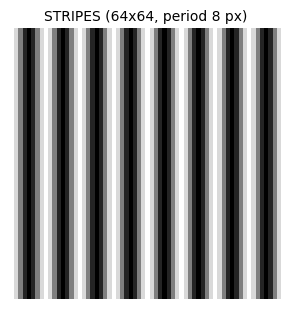

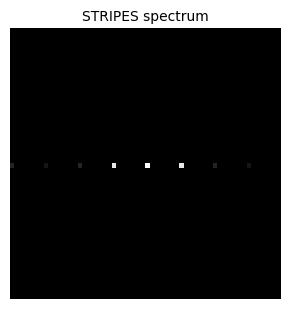

Predicted: (u,v) = (8,0) and (-8,0)
Found: [[-8  0]
 [ 0  0]
 [ 8  0]]


In [ ]:
show(STRIPES, "STRIPES (64x64, period 8 px)")

# YOUR CODE for part (c): compute the spectrum and find the peak locations.
# Hint: np.argwhere(A > 0.5*A.max()) on the shifted amplitude, then subtract
# the centre index to get coordinates relative to the origin.

show(spectrum(STRIPES), "DFT Amplitude")

# shifted amplitude spectrum
L_shifted = fftshift(fft2(STRIPES)) # Equation 16.4(Equation 16.2())
amplitude = np.abs(L_shifted); # Section 16.5.3: Split a complex transform L=A[u,v]exp(jθ[u,v])

# peak locations
peaks = np.argwhere(amplitude > 0.5 * amplitude.max()) # Section 16.9 Rule Two: Repetition Makes Dots
# print(peaks) # STRIPES produces sharp dots due to transform (1/2)​(δ[u−u0​,v−v0​]+δ[u+u0​,v+v0​])

# array indices to frequency coordinates
center = np.array(STRIPES.shape) // 2 # [64, 64] = [32, 32]
frequency_coordinates = peaks - center
# print(frequency_coordinates)

print("Predicted: (u,v) = (8,0) and (-8,0)")
print("Found:", frequency_coordinates[:, ::-1])


### Your answer

**(a)** Based off Example 1 in Section 16.10.1, I predict the $(u,v)$ frequency coordinates to be $(8,0)$ and $(-8,0)$.

Since `STRIPES` is $64\times64$ image with the pattern every $8$ pixels:

* Image Width: $N=64$
* Stripe Period: $P=8$
* Peaks: $u=N/P=64/8=8$, since the stripes don't vary vertically $v=0$
* Conjugate Symmetry: $(-u,-v)=(-8,0)$

**(b)** The peaks appear in pairs because as conjugate symmetry suggests, the real-valued image of `STRIPES` has its frequency $(u,v)$ and its complex conjugate $(-u,-v)$ since their amplitudes are the same. Since a pure sinusoid is the sum of the exponentials at the same frequency, it is necessary for both to exist so their imaginary parts cancel and a real-valued signal is returned.

From Section 16.5.3, *The image is real, so its transform has conjugate symmetry: $\mathscr{L}[−u,−v]=\mathscr{L}^*[u,v]$. Take one coefficient without its partner and the reconstruction comes out complex. Add the pair and the imaginary parts cancel, leaving a cosine. Equal amplitudes give a cosine; opposite amplitudes give a sine.*

**(c)** My prediction was mostly correct except for an unseen DC peak at $(0,0)$. I think I misunderstood the fact that I also should have accounted for the brightness of the image and not just the pattern oscillation.

In [ ]:
# Your code, if you need more room.


---

## Question 4 — Amplitude against phase  *(12 points)*

Take `BOAT` and `BUILDING`. Compute both transforms, then build two hybrids: the **amplitude of one** combined with the **phase of the other**, and vice versa.

**(a) [0]** **Before running anything**, predict which parent each hybrid will resemble. Write the prediction down.

**(b) [6]** Produce the two hybrids and describe what you see.

**(c) [6]** The conclusion *"all the information is in the phase"* is too strong. Repeat the experiment on `TEXTURE` and on `FACADE`, this time comparing

- the **true amplitude** with a randomised phase, against
- a generic $1/f$ amplitude with the **true phase**.

For which image does amplitude win? Explain what property of that image is responsible, and say where `FACADE` sits between the two extremes.

*Hint: what kind of image has a spectrum made of a few isolated points rather than a broad smear?*

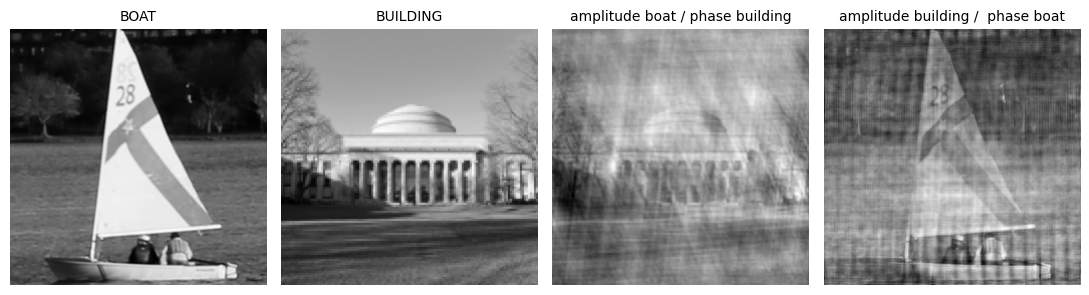

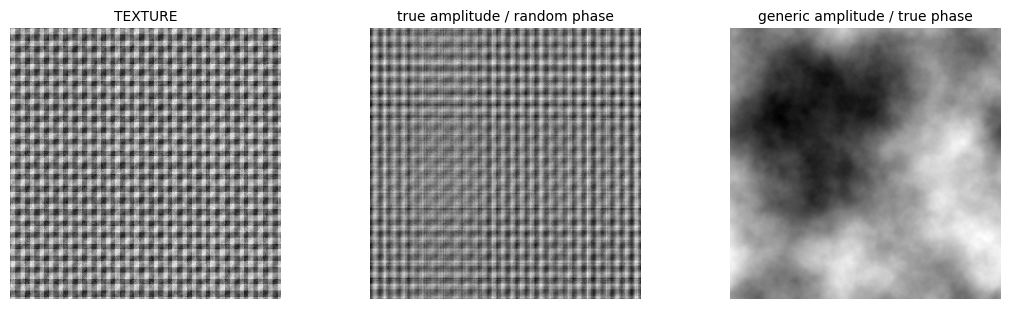

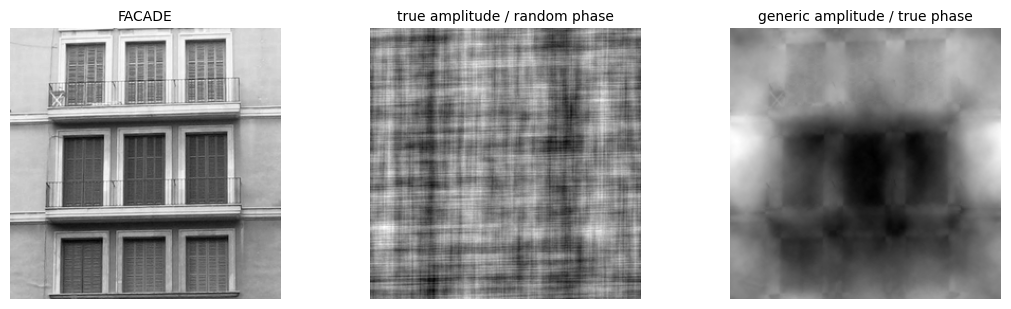

In [17]:
def to_polar(img):
    """Return (amplitude, phase) of the 2D DFT of img."""
    L = fft2(img)
    return np.abs(L), np.angle(L)

def from_polar(amp, phase):
    """Rebuild a real image from an amplitude and a phase."""
    return np.real(ifft2(amp * np.exp(1j * phase)))

# YOUR CODE (b): build the two hybrids and show them.
amplitude_boat, phase_boat = to_polar(BOAT)
amplitude_building, phase_building = to_polar(BUILDING)

# build hybrids
hybrid1 = from_polar(amplitude_boat, phase_building)
hybrid2 = from_polar(amplitude_building, phase_boat)

show(BOAT, "BOAT", BUILDING, "BUILDING", hybrid1, "amplitude boat / phase building", hybrid2, "amplitude building /  phase boat")

# YOUR CODE (c): run the comparison on TEXTURE, FACADE and BOAT.
# The helper below gives you the generic amplitude.
def random_phase(shape):
    """Uniform random phase in [-pi, pi], same shape as the image."""
    return np.random.uniform(-np.pi, np.pi, size=shape)

def generic_amplitude(shape, b=1.0):
    """A 1/(u^2+v^2)^b amplitude spectrum - the average natural image."""
    M, N = shape
    u = fftshift(np.arange(M) - M//2); v = fftshift(np.arange(N) - N//2)
    U, V = np.meshgrid(u, v, indexing="ij")
    r2 = U**2 + V**2; r2[0, 0] = 1.0
    A = 1.0 / r2**b
    A[0, 0] = A.max() * 10
    return A

amplitude_texture, phase_texture = to_polar(TEXTURE)
amplitude_facade, phase_facade = to_polar(FACADE)

hybrid3 = from_polar(amplitude_texture, random_phase(TEXTURE.shape))
hybrid4 = from_polar(generic_amplitude(TEXTURE.shape), phase_texture)
hybrid5 = from_polar(amplitude_facade, random_phase(FACADE.shape))
hybrid6 = from_polar(generic_amplitude(FACADE.shape), phase_facade)

show(TEXTURE, "TEXTURE", hybrid3, "true amplitude / random phase", hybrid4, "generic amplitude / true phase")
show(FACADE, "FACADE", hybrid5, "true amplitude / random phase", hybrid6, "generic amplitude / true phase")

### Your answer

**(a)** Based off Section 16.9 and Section 16.5.3, *location information goes into phase; intensity scaling goes into the magnitude*. I think the parent each hybrid would resemble would be the one that donated its phase, so $BOATS AMPLITUDE + BUILDINGS PHASE$ should resemble $BUILDING$ and $BUILDINGS AMPLITUDE + BOATS PHASE$ should resemble $BOAT$.

**(b)** This basically confirms my prediction. Having produced both hybrids, hybrid1 has the building more prominent and hybrid2 has the boat more prominently showing. It seems like the shape information is aligned more towards the phase donor. That being said it seems like hybrid1 has a bit of `BOAT`s amplitude spectrum bleeding through, giving it a grainy texture. In hybrid2, there seems to be vertical lines across the whole image from `BUILDING`s amplitude due to the horizontal edges. So the amplitude is still somewhat visible in the hybrid images from the contrast and texture.

**(c)** It seems that for the `TEXTURE` image, the application of amplitute seems to matter more than phase as it was able to maintain some semblance of the image, unlike when true amplitude isn't present  the image is essentially lost. For the `FACADE` image, it seems like it had the opposite effect and true phase is much more essential to the structure of retaining the original image. `TEXTURE` in this case is similar to `STRIPES` as it is periodic and relies on amplitude and the strength of the frequences present. As for `FACADE`, I would say it is a little bit closer to what `BUILDING` and `BOAT` are as there is clearly defined edges and outline and it shows true phase carrying in that sense, but it isn't purely that either as you can also see patterns in the true amplitude. As you can see above thought `FACADE` isn't clearly defined by either and so it sits between these two extremes.

In [ ]:
# Your code, if you need more room.


---

## Question 5 — Two shifts  *(10 points)*

**(a) [6]** Shift `BUILDING` by $7$ pixels horizontally. Show numerically that the **amplitude spectrum is unchanged**. Then show that the phase changed, and describe the pattern: how does the phase difference vary with the frequency index?

**(b) [4]** Multiply `BUILDING` pointwise by $(-1)^{n+m}$ and then transform it. Describe what happened to the spectrum, and explain it using the modulation property.
PS: You may want to use fftshift.



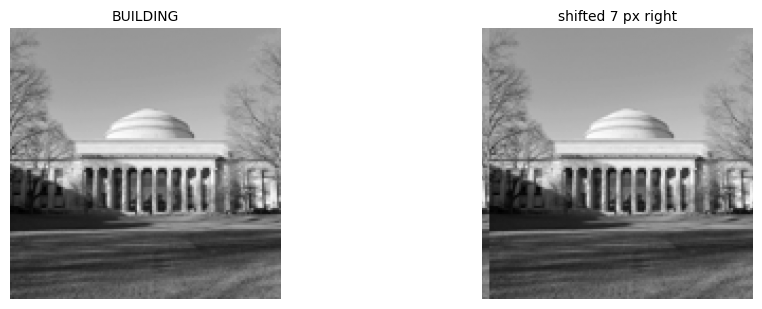

True


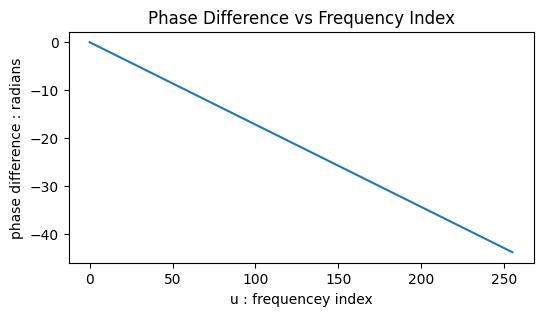

Measured slope: -0.17181 rad/unit
Predicted slope: -0.17181 rad/unit


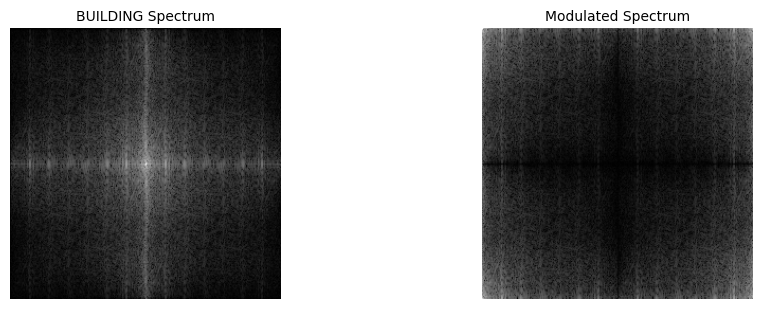

In [22]:
shifted = np.roll(BUILDING, 7, axis=1)
show(BUILDING, "BUILDING", shifted, "shifted 7 px right")

# YOUR CODE (a): compare the two amplitude spectra, then look at the phase
# difference as a function of frequency index. np.angle and np.unwrap help.

# computed spectra for orignal image and shifted image
L_original = fft2(BUILDING)
L_shifted = fft2(shifted)

# compared amplitudes
amplitude_original = np.abs(L_original)
amplitude_shifted = np.abs(L_shifted)
print(np.allclose(amplitude_original, amplitude_shifted))

# get phase angles and unwrap
phase_original = np.angle(L_original)
phase_shifted = np.angle(L_shifted)
phase_difference = np.unwrap(phase_shifted - phase_original, axis=1)

plt.figure(figsize=(6,3))
plt.plot(phase_difference[0])
plt.title("Phase Difference vs Frequency Index")
plt.xlabel("u : frequencey index")
plt.ylabel("phase difference : radians")
plt.show()

u_values = np.arange(len(phase_difference[0]))
slope, intercept = np.polyfit(u_values, phase_difference[0], 1)

print(f"Measured slope: {slope:.5f} rad/unit")
print(f"Predicted slope: {-2*np.pi*7/256:.5f} rad/unit") # Equation 16.7

# YOUR CODE (b): build the (-1)^(n+m) checkerboard and multiply.
n, m = np.meshgrid(np.arange(256), np.arange(256), indexing="ij")
checkerboard = (-1)**(n+m)

modulated = BUILDING * checkerboard

L_original = fftshift(fft2(BUILDING))
L_modulated = fftshift(fft2(modulated))

show(spectrum(BUILDING), "BUILDING Spectrum", spectrum(modulated), "Modulated Spectrum")


### Your answer

**(a)** From Section 16.7.6, Equation 16.7 \(shift in space) is magnitude untouched and only the phase moves. To confirm that the amplitude stays unchanged, I applied this `allclose()` function to determine if there's a difference in amplitude between the shifte and original `BUILDING` image. Since `np.allclose(amplitude_original, amplitude_shifted)` returns true, I confirmed that the amplitude spectrum is unchanged. As for the change in phase, as it decreases linearly, the frequency index increases. Using the equation 16.7, $-2\pi(un_0/N)=-2\pi(7)/256=-0.172 rad/unit$ and the calculated slope from the graph above, I was able to confirm the purely horizontal shift. The phase difference varies as a higher frequency has more phase rotation per unit shift and a lower frequency has barely any phase change under a shift.

**(b)** From Section 16.7.7, Equation 16.8 \(shift in frequency) is modulation. The original image had strong lines vertically and horizontally with the bright DC at the center. The modulated image is basically inverted and has cross patter is more so towards the edges as the center is way darker now. This occurred as the modulation property $(-1)^{n+m}=\exp(j\pi(n+m))$ is the same as Equation 16.8 with $u_0=v_0=N/2$. Essentially a modulation keeps the shape of the spectrum alone but moves it entirely.

In [ ]:
# Your code, if you need more room.


---

## Question 6 — Convolution two ways  *(10 points)*

**(a) [4]** Convolve `BOAT` with a $15\times15$ Gaussian kernel directly. Then do the same via the FFT: transform both, multiply pointwise, transform back. Confirm the two agree.

**(b) [3]** Time both methods for kernel sizes $3, 7, 15, 31, 63$. Report the crossover size at which the FFT route becomes faster.

**(c) [3]** The two results agree *almost* everywhere. Where do they differ, and why? Your answer should mention boundary conditions.

False


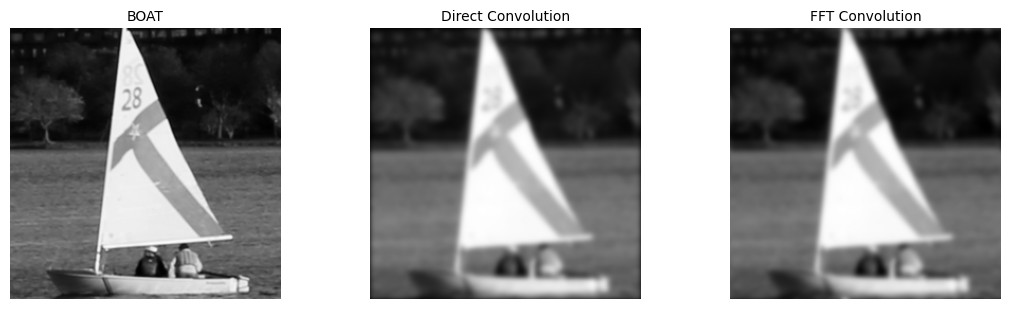

size=3: direct=0.00299s, fft=0.01101s
size=7: direct=0.01300s, fft=0.01200s
size=15: direct=0.05653s, fft=0.00900s
size=31: direct=0.19606s, fft=0.01100s
size=63: direct=0.89150s, fft=0.01100s


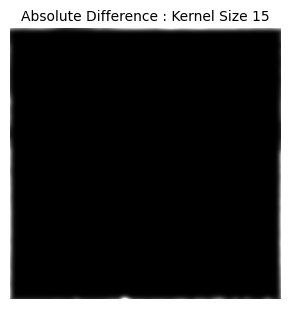

Max Difference: 0.2687989621160458
Max Difference Location: (np.int64(255), np.int64(108))
Interior Agreement: True


In [27]:
import time
from scipy.signal import convolve2d

def gaussian_kernel(size, sigma=None):
    """A normalised square Gaussian kernel."""
    if sigma is None: sigma = size/6.0
    a = np.arange(size) - (size-1)/2
    g = np.exp(-a**2/(2*sigma**2))
    k = np.outer(g, g)
    return k / k.sum()

def fft_convolve(img, kernel):
    """Circular convolution via the FFT, kernel centred."""
    K = np.zeros_like(img)
    s = kernel.shape[0]; c = s//2
    K[:s, :s] = kernel
    K = np.roll(K, (-c, -c), axis=(0, 1))     # put the kernel centre at [0,0]
    return np.real(ifft2(fft2(img) * fft2(K)))

# YOUR CODE (a): compare convolve2d(..., mode="same") with fft_convolve.
kernel = gaussian_kernel(15)

direct = convolve2d(BOAT, kernel, mode="same")
fft = fft_convolve(BOAT, kernel)

print(np.allclose(direct, fft, atol=1e-6))
show(BOAT, "BOAT", direct, "Direct Convolution", fft, "FFT Convolution")

# YOUR CODE (b): time both for several kernel sizes.
sizes = [3, 7, 15, 31, 63]
for s in sizes:
    k = gaussian_kernel(s)

    t0 = time.time()
    convolve2d(BOAT, k, mode="same")
    t_direct = time.time() - t0
    t0 = time.time()

    fft_convolve(BOAT, k)
    t_fft = time.time() - t0

    print(f"size={s}: direct={t_direct:.5f}s, fft={t_fft:.5f}s")


# YOUR CODE (c): look at where they differ - try imshow of the absolute difference.
difference = np.abs(direct - fft)
show(difference, "Absolute Difference : Kernel Size 15")
print("Max Difference:", difference.max())
print("Max Difference Location:", np.unravel_index(np.argmax(difference), difference.shape))
print("Interior Agreement:", np.allclose(direct[15:-15, 15:-15], fft[15:-15, 15:-15], atol=1e-6))


### Your answer

**(a)** In Section 16.7.4 the colvolution becomes multiplications and multiplication becomes convolution. The `BOAT` images of Direct and FFT Convolution look very similar the only difference would be a very small one that is more so relegated to the edges while the interior of the images are mostly the same. Both images look very similarly blurred. I used `np.allclose(direct, fft, atol=1e-6)` to check their difference overall and it returned false due to the edges, but once I restricted the comparison to the interior `np.allclose(direct[15:-15, 15:-15], fft[15:-15, 15:-15], atol=1e-6)` within the bounds of the edges it returned true. So this shows that the two agree which supports the convolution theorem.

**(b)** Direct convolution's timing increased as the kernel size increased and FFT convolution's timing stayed relatively the same as kernel size increased. In this run, direct is faster only in the smallest kernel size, 3. By kernel size 7, FFT is already slightly faster. The runtime for direct grows almost quadratically which is consistent with the theory. FFT seems to barely depend on the kernel size at all. I would say the crossover point is $k=3$ and $k=7$.

$size=3: direct=0.00299s, fft=0.01101s$
$size=7: direct=0.01300s, fft=0.01200s$
$size=15: direct=0.05653s, fft=0.00900s$
$size=31: direct=0.19606s, fft=0.01100s$
$size=63: direct=0.89150s, fft=0.01100s$

**(c)** Using mode="same" with convolve2d essentially zero-pads the image at the border, so the pixels at the edge are convolved against the black picels outside the `BOAT` image. With fft_convolve, the circular convolution has DFT assume image wrapping occurs periodically. Knowing what's outside the image matters only if the kernel support reaches past the boundary, which I find both results essentially agreeing with each other everywhere except the edges.

In [ ]:
# Your code, if you need more room.

---

*Images adapted from* Foundations of Computer Vision *by Torralba, Isola and Freeman
(visionbook.mit.edu), CC BY-NC-ND, for non-commercial classroom use.*